In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# /content/drive/MyDrive/MLproject /insurance.csv

In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv("/content/drive/MyDrive/MLproject /insurance.csv")

In [ ]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
data.shape

(1338, 7)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
data.shape

(1338, 7)

In [ ]:
data.skew(numeric_only=True)

,0
age,0.055673
bmi,0.284047
children,0.938380
charges,1.515880


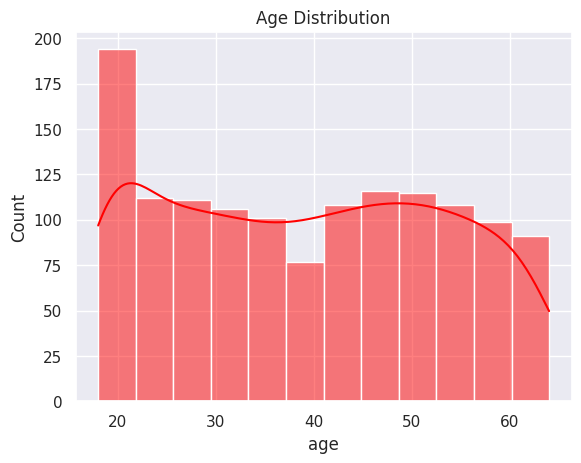

In [ ]:
sns.set_theme(style="darkgrid")
sns.histplot(data['age'],kde=True,color="red")
plt.title('Age Distribution')
plt.xlabel('age')
plt.show()

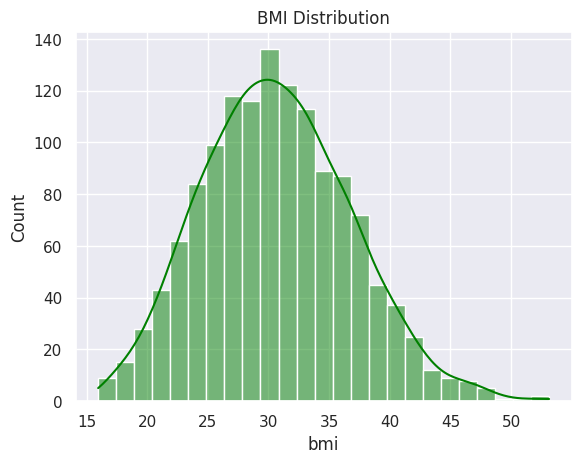

In [ ]:
sns.set_theme(style="darkgrid")
sns.histplot(data['bmi'],kde=True,color="green")
plt.title('BMI Distribution')
plt.xlabel('bmi')
plt.show()

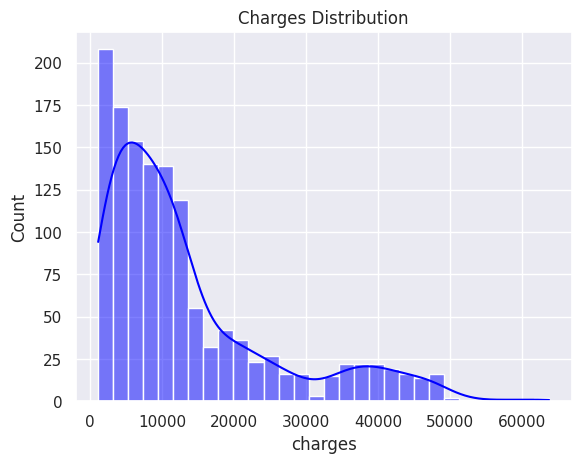

In [ ]:
sns.set_theme(style="darkgrid")
sns.histplot(data['charges'],kde=True,color="blue")
plt.title('Charges Distribution')
plt.xlabel('charges')
plt.show()

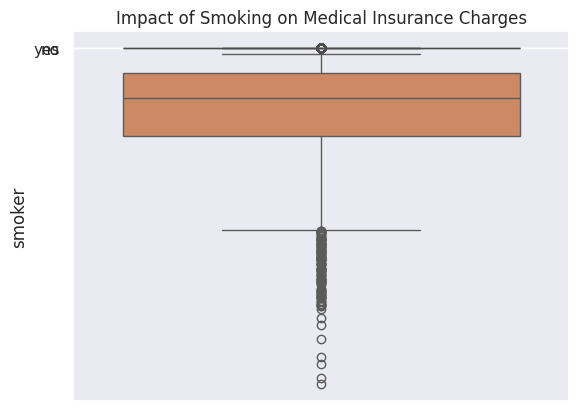

In [ ]:

sns.boxplot(data['smoker'])
sns.boxplot(data['charges'])
plt.title("Impact of Smoking on Medical Insurance Charges")
plt.show()

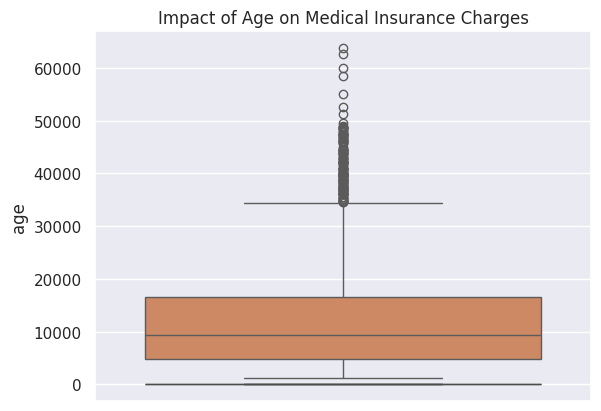

In [ ]:
sns.boxplot(data['age'])
sns.boxplot(data['charges'])
plt.title("Impact of Age on Medical Insurance Charges")
plt.show()


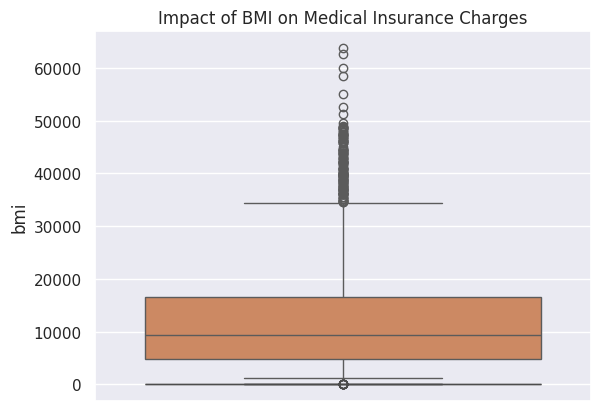

In [ ]:
sns.boxplot(data['bmi'])
sns.boxplot(data['charges'])
plt.title("Impact of BMI on Medical Insurance Charges")
plt.show()

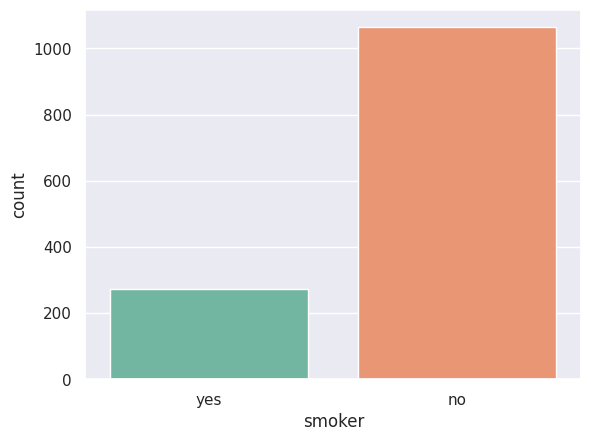

In [ ]:
sns.countplot(data=data,x="smoker",hue="smoker",palette="Set2")
plt.show()

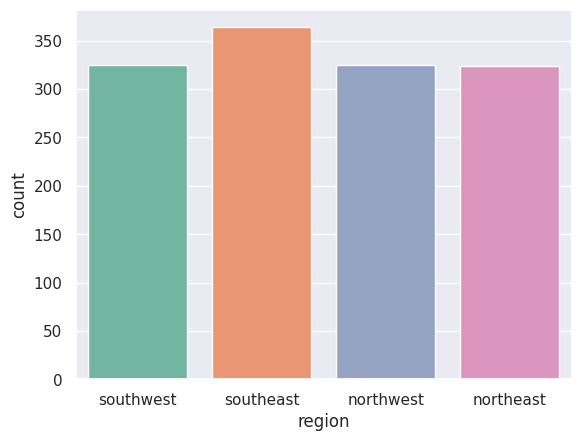

In [ ]:
sns.countplot(data=data,x="region",hue="region",palette="Set2")
plt.show()

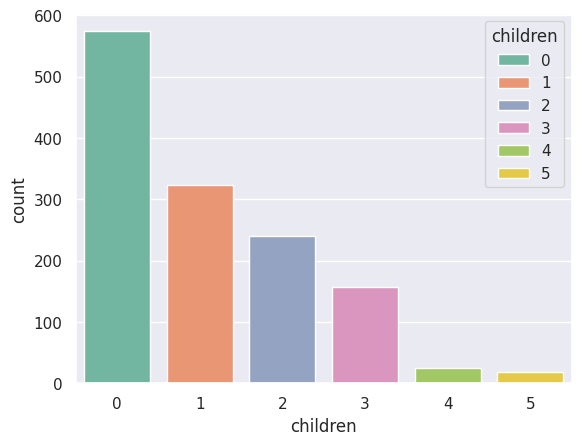

In [ ]:
sns.countplot(data=data,x="children",hue="children",palette="Set2")
plt.show()

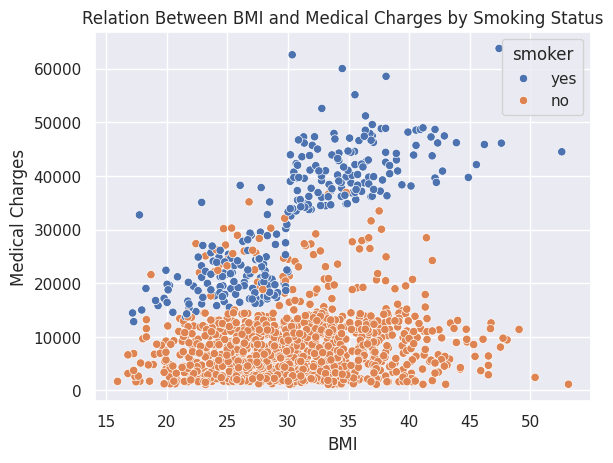

In [ ]:
sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')
plt.title("Relation Between BMI and Medical Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()


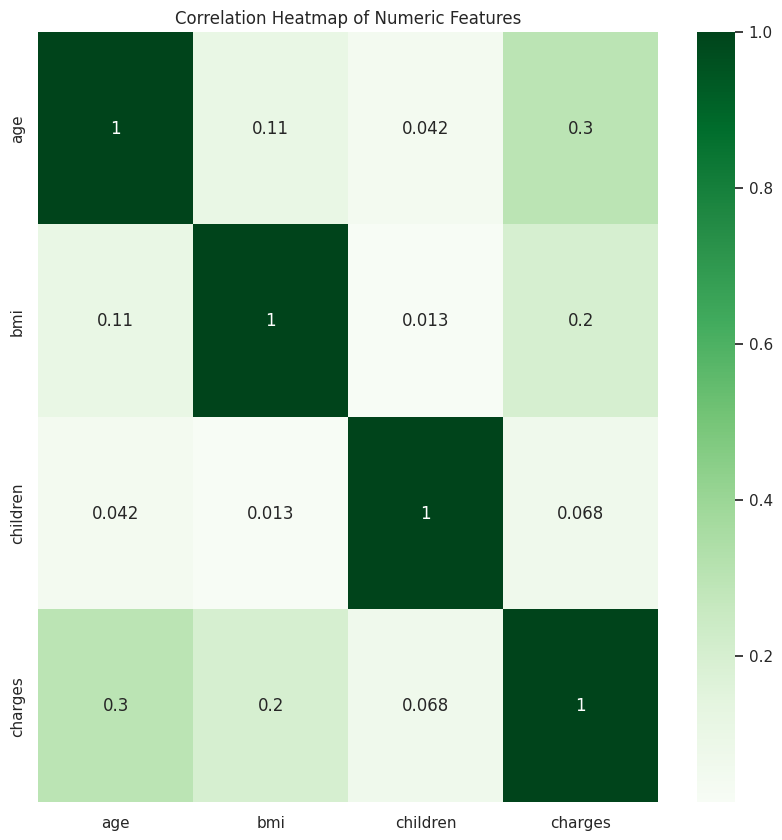

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data.select_dtypes(include='number').corr(),annot=True, cmap="Greens")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
scaler = StandardScaler()

# Encode categorical columns
data['sex'] = le.fit_transform(data['sex'])
data['smoker'] = le.fit_transform(data['smoker'])
data['region'] = le.fit_transform(data['region'])

# Scale numerical columns
data[['age', 'bmi', 'children', 'charges']] = scaler.fit_transform(
    data[['age', 'bmi', 'children', 'charges']]
)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=data.drop("charges",axis=1) # spltting to target and Features variable
y=data["charges"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42 )

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

 # fitting model
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
# predicting
y_pred=lr.predict(x_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MAE is",mae)
print("MSE is",mse)
print("R2 is",r2)

MAE is 0.3458357023132986
MSE is 0.22952487683968578
R2 is 0.7833463107364538


In [ ]:
#decision tree
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor ()
dtr.fit(x_train,y_train)

y_pred_dtr=dtr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred_dtr)
mse=mean_squared_error(y_test,y_pred_dtr)
r2=r2_score(y_test,y_pred_dtr)
print("MAE is",mae)
print("MSE is",mse)
print("R2 is",r2)

MAE is 0.23978610057276314
MSE is 0.29770090496919577
R2 is 0.7189934256942353


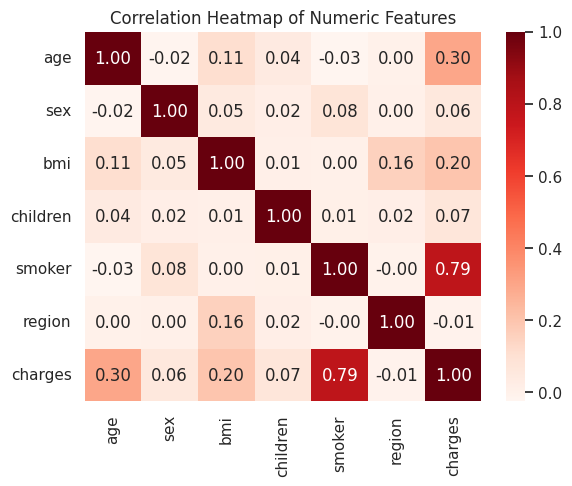

In [ ]:
sns.heatmap(data.select_dtypes(include='number').corr(),annot=True,fmt=".2f",cmap="Reds")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
# Random Tree
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=100,random_state=42)
rfr.fit(x_train,y_train)

y_pred_rfr=rfr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred_rfr)
mse=mean_squared_error(y_test,y_pred_rfr)
r2=r2_score(y_test,y_pred_rfr)
print("MAE is",mae)
print("MSE is",mse)
print("R2 is",r2)

MAE is 0.20798522874317169
MSE is 0.14269784616922296
R2 is 0.865304296213095


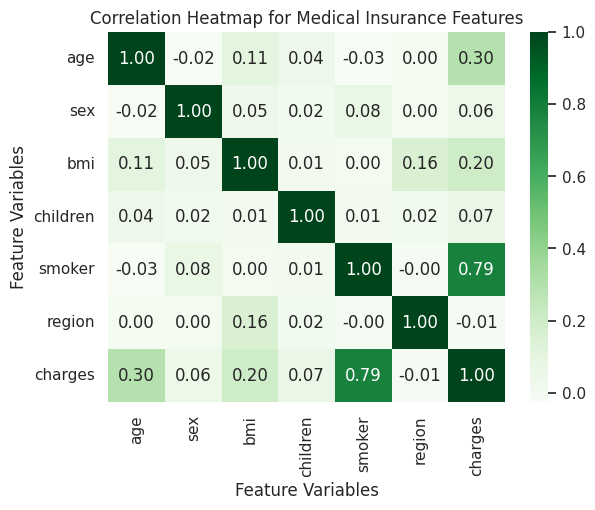

In [ ]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="Greens")
plt.title("Correlation Heatmap for Medical Insurance Features")
plt.xlabel("Feature Variables")
plt.ylabel("Feature Variables")
plt.show()


In [ ]:
# for XG boost
from sklearn.ensemble import GradientBoostingRegressor
gbr=GradientBoostingRegressor()
gbr.fit(x_train,y_train)

y_pred_gbr=gbr.predict(x_test)
mae=mean_absolute_error(y_test,y_pred_gbr)
mse=mean_squared_error(y_test,y_pred_gbr)
r2=r2_score(y_test,y_pred_gbr)
print("MAE is",mae)
print("MSE is",mse)
print("R2 is",r2)

MAE is 0.20218594656827785
MSE is 0.12961704262858179
R2 is 0.8776515606344197


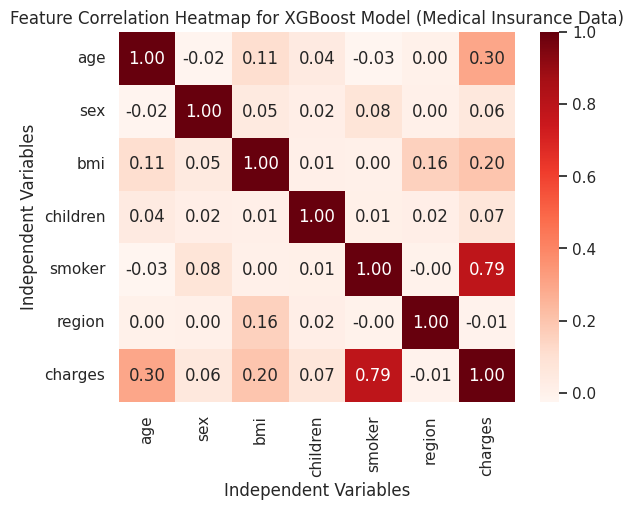

In [ ]:
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap="Reds")
plt.title("Feature Correlation Heatmap for XGBoost Model (Medical Insurance Data)")
plt.xlabel("Independent Variables")
plt.ylabel("Independent Variables")
plt.show()

In [ ]:
importance=gbr.feature_importances_  # features ka naam h
features = x.columns
fea_imp=pd.DataFrame({"Features":features,"Importance":importance})
fea_imp=fea_imp.sort_values(by="Importance",ascending=False)#sorting importance descending
fea_imp.head(5)

,Features,Importance
4,smoker,0.677868
2,bmi,0.189976
0,age,0.117745
3,children,0.010149
5,region,0.003568


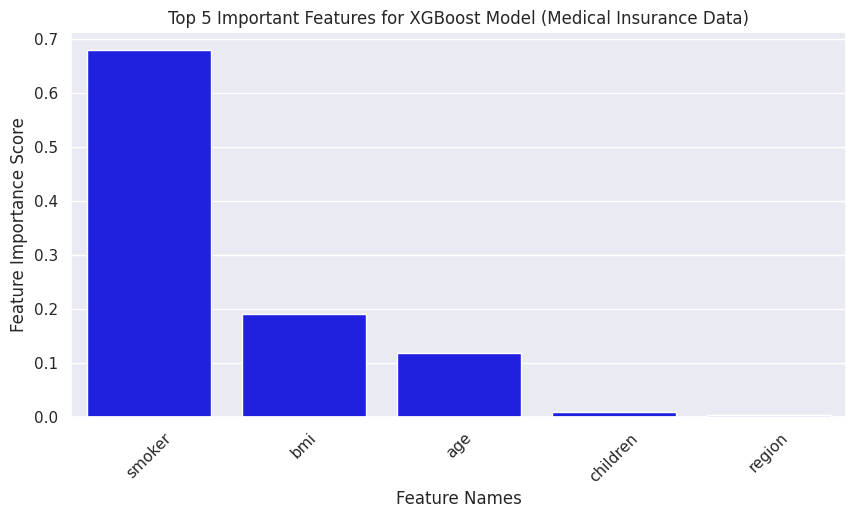

In [ ]:
plt.figure(figsize=(10,5))
top_features = fea_imp.head(5) # Select the top 5 features
sns.barplot(x="Features", y="Importance", data=top_features, color="blue")
plt.title("Top 5 Important Features for XGBoost Model (Medical Insurance Data)")
plt.xlabel("Feature Names")
plt.ylabel("Feature Importance Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(gbr,"Insurance_type_dtc.pkl")
['Insurance _type_dtc.pkl']

['Insurance _type_dtc.pkl']

In [ ]:
from google.colab import files
files.download("Insurance_type_dtc.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
uploaded=files.upload()

Saving Insurance_type_dtc.pkl to Insurance_type_dtc (1).pkl


In [ ]:
model=joblib.load("Insurance_type_dtc.pkl")